In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
%matplotlib inline

In [ ]:
df = pd.read_csv(
     filepath_or_buffer='https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data',
     header=None,
     sep=',')
df.columns=['sepal_len', 'sepal_wid', 'petal_len', 'petal_wid', 'class']
print(df.isnull().values.any())
df.dropna(how="all", inplace=True) # drops the empty line at file-end

#if inplace = False then we have to assign back to dataframe as it is a copy
#df = df.some_operation(inplace=False)

#No need to assign back to dataframe when inplace = True
#df.some_operation(inplace=True)

#Print Last five rows.
df.tail()

False


,sepal_len,sepal_wid,petal_len,petal_wid,class
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [ ]:
X = df.iloc[:,0:4].values
y = df.iloc[:,4].values

In [ ]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
y

array(['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versic

In [ ]:
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)

In [ ]:
X_std
#In the output screen shot below you see that all X_std values are standardized in the range of -1 to +1.

array([[-9.00681170e-01,  1.03205722e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00, -1.24957601e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.38535265e+00,  3.37848329e-01, -1.39813811e+00,
        -1.31297673e+00],
       [-1.50652052e+00,  1.06445364e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.02184904e+00,  1.26346019e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-5.37177559e-01,  1.95766909e+00, -1.17067529e+00,
        -1.05003079e+00],
       [-1.50652052e+00,  8.00654259e-01, -1.34127240e+00,
        -1.18150376e+00],
       [-1.02184904e+00,  8.00654259e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.74885626e+00, -3.56360566e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00,  1.06445364e-01, -1.28440670e+00,
        -1.44444970e+00],
       [-5.37177559e-01,  1.49486315e+00, -1.28440670e+00,
        -1.31297673e+00],
       [-1.26418478e+00,  8.00654259e-01, -1.22754100e+00,
      

In [ ]:
#mean_vec = np.mean(X_std, axis=0)
#cov_mat = (X_std - mean_vec).T.dot((X_std - mean_vec)) / (X_std.shape[0]-1)
#print('Covariance matrix \n%s' %cov_mat)
print('Covariance matrix \n')
cov_mat= np.cov(X_std, rowvar=False)
cov_mat

Covariance matrix 



array([[ 1.00671141, -0.11010327,  0.87760486,  0.82344326],
       [-0.11010327,  1.00671141, -0.42333835, -0.358937  ],
       [ 0.87760486, -0.42333835,  1.00671141,  0.96921855],
       [ 0.82344326, -0.358937  ,  0.96921855,  1.00671141]])

In [ ]:
cov_mat = np.cov(X_std.T)
eig_vals, eig_vecs = np.linalg.eig(cov_mat)
print('Eigenvectors \n%s' %eig_vecs)
print('\nEigenvalues \n%s' %eig_vals)

Eigenvectors 
[[ 0.52237162 -0.37231836 -0.72101681  0.26199559]
 [-0.26335492 -0.92555649  0.24203288 -0.12413481]
 [ 0.58125401 -0.02109478  0.14089226 -0.80115427]
 [ 0.56561105 -0.06541577  0.6338014   0.52354627]]

Eigenvalues 
[2.93035378 0.92740362 0.14834223 0.02074601]


In [ ]:
sq_eig_sums = []
for i in eig_vecs:
    sq_eig_sums.append(np.sum(i**2))

print("Sum of squares for each eigenvector:")
for i, sum_sq in enumerate(sq_eig_sums):
    print(f"Eigenvector {i+1}: {sum_sq:.6f}")

# Verify that each eigenvector is normalized (sum of squares is close to 1)
for ev in eig_vecs.T: # Iterate over rows (eigenvectors)
    np.testing.assert_array_almost_equal(1.0, np.linalg.norm(ev))

print("\nAll eigenvectors are normalized.")

Sum of squares for each eigenvector:
Eigenvector 1: 1.000000
Eigenvector 2: 1.000000
Eigenvector 3: 1.000000
Eigenvector 4: 1.000000

All eigenvectors are normalized.


In [ ]:
#Make a list of (eigenvalue, eigenvector) tuples
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[:,i]) for i in range(len(eig_vals))]
#Sort the (eigenvalue, eigenvector) tuples from high to low
eig_pairs.sort()
eig_pairs.reverse()
print("\n",eig_pairs)
#Visually confirm that the list is correctly sorted by decreasing eigenvalues
print('\n\n\nEigenvalues in descending order:')
for i in eig_pairs:
    print(i[0])


 [(np.float64(2.930353775589317), array([ 0.52237162, -0.26335492,  0.58125401,  0.56561105])), (np.float64(0.9274036215173419), array([-0.37231836, -0.92555649, -0.02109478, -0.06541577])), (np.float64(0.14834222648163944), array([-0.72101681,  0.24203288,  0.14089226,  0.6338014 ])), (np.float64(0.02074601399559593), array([ 0.26199559, -0.12413481, -0.80115427,  0.52354627]))]



Eigenvalues in descending order:
2.930353775589317
0.9274036215173419
0.14834222648163944
0.02074601399559593


In [ ]:
tot = sum(eig_vals)
print("\n",tot)
var_exp = [(i / tot)*100 for i in sorted(eig_vals, reverse=True)]
print("\n\n1. Variance Explained\n",var_exp)
cum_var_exp = np.cumsum(var_exp)
print("\n\n2. Cumulative Variance Explained\n",cum_var_exp)
print("\n\n3. Percentage of variance the first two principal components each contain\n ",var_exp[0:2])
print("\n\n4. Percentage of variance the first two principal components together contain\n",sum(var_exp[0:2]))


 4.026845637583894


1. Variance Explained
 [np.float64(72.77045209380135), np.float64(23.03052326768065), np.float64(3.683831957627379), np.float64(0.5151926808906321)]


2. Cumulative Variance Explained
 [ 72.77045209  95.80097536  99.48480732 100.        ]


3. Percentage of variance the first two principal components each contain
  [np.float64(72.77045209380135), np.float64(23.03052326768065)]


4. Percentage of variance the first two principal components together contain
 95.800975361482


In [ ]:
print(eig_pairs[0][1])
print(eig_pairs[1][1])
matrix_w = np.hstack((eig_pairs[0][1].reshape(4,1),
                      eig_pairs[1][1].reshape(4,1)))
#hstack: Stacks arrays in sequence horizontally (column wise).
print('Matrix W:\n', matrix_w)

[ 0.52237162 -0.26335492  0.58125401  0.56561105]
[-0.37231836 -0.92555649 -0.02109478 -0.06541577]
Matrix W:
 [[ 0.52237162 -0.37231836]
 [-0.26335492 -0.92555649]
 [ 0.58125401 -0.02109478]
 [ 0.56561105 -0.06541577]]


In [ ]:
# Projecting the standardized data onto the new feature subspace
Y = X_std.dot(matrix_w)

# Creating a DataFrame with the principal components
principalDf = pd.DataFrame(
    data=Y,
    columns=['principal component 1', 'principal component 2']
)

# Displaying the first few rows
principalDf.head()


,principal component 1,principal component 2
0,-2.264542,-0.505704
1,-2.086426,0.655405
2,-2.367950,0.318477
3,-2.304197,0.575368
4,-2.388777,-0.674767


In [ ]:
finalDf = pd.concat([principalDf,pd.DataFrame(y,columns = ['species'])], axis = 1)
finalDf.head()

,principal component 1,principal component 2,species
0,-2.264542,-0.505704,Iris-setosa
1,-2.086426,0.655405,Iris-setosa
2,-2.367950,0.318477,Iris-setosa
3,-2.304197,0.575368,Iris-setosa
4,-2.388777,-0.674767,Iris-setosa


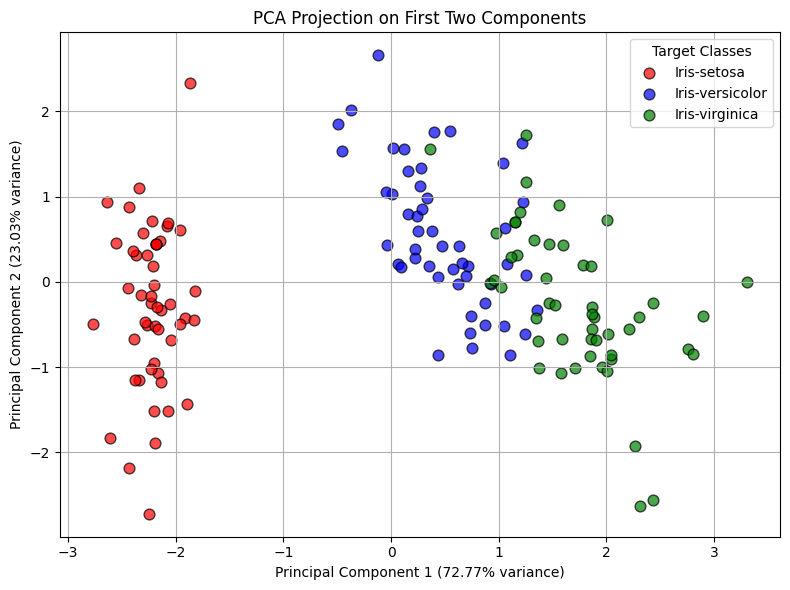

In [ ]:
# --- PCA Scatter Plot with Proper Axes and Labels ---

import matplotlib.pyplot as plt

# 'principalDf' has the two PCA columns
# 'y' is your target variable (e.g., species or diagnosis)
# 'pca' is your fitted PCA model

finalDf = pd.concat([principalDf, pd.DataFrame(y, columns=['target'])], axis=1)

# Calculate variance explained by each component
explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(8,6))

# Choose unique target classes and colors
targets = np.unique(y)
colors = ['red', 'blue', 'green']

for target, color in zip(targets, colors):
    subset = finalDf[finalDf['target'] == target]
    plt.scatter(
        subset['principal component 1'],
        subset['principal component 2'],
        label=str(target),
        color=color,
        s=60,
        alpha=0.7,
        edgecolor='k'
    )

# Axis labels now included!
plt.xlabel(f"Principal Component 1 ({explained_var[0]*100:.2f}% variance)")
plt.ylabel(f"Principal Component 2 ({explained_var[1]*100:.2f}% variance)")

plt.title("PCA Projection on First Two Components")
plt.legend(title='Target Classes')
plt.grid(True)
plt.tight_layout()
plt.show()


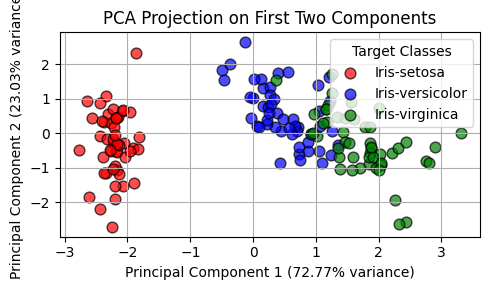

In [ ]:
# --- PCA Scatter Plot with Proper Axes and Labels ---

import matplotlib.pyplot as plt

# 'principalDf' has the two PCA columns
# 'y' is your target variable (e.g., species or diagnosis)
# 'pca' is your fitted PCA model

finalDf = pd.concat([principalDf, pd.DataFrame(y, columns=['target'])], axis=1)

# Calculate variance explained by each component
explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(5,3))

# Choose unique target classes and colors
targets = np.unique(y)
colors = ['red', 'blue', 'green']

for target, color in zip(targets, colors):
    subset = finalDf[finalDf['target'] == target]
    plt.scatter(
        subset['principal component 1'],
        subset['principal component 2'],
        label=str(target),
        color=color,
        s=60,
        alpha=0.7,
        edgecolor='k'
    )

# Axis labels now included!
plt.xlabel(f"Principal Component 1 ({explained_var[0]*100:.2f}% variance)")
plt.ylabel(f"Principal Component 2 ({explained_var[1]*100:.2f}% variance)")

plt.title("PCA Projection on First Two Components")
plt.legend(title='Target Classes')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
pca = PCA(n_components=2) # Here we can also give the percentage as a paramter to the PCA function as pca = PCA(.95). .95 means that we want to include 95% of the variance. Hence PCA will return the no of components which describe 95% of the variance. However we know from above computation that 2 components are enough so we have passed the 2 components.
principalComponents = pca.fit_transform(X_std)
principalDf = pd.DataFrame(data = principalComponents
              , columns = ['principal component 1', 'principal component 2'])
principalDf.head(5) # prints the top 5 rows

,principal component 1,principal component 2
0,-2.264542,0.505704
1,-2.086426,-0.655405
2,-2.367950,-0.318477
3,-2.304197,-0.575368
4,-2.388777,0.674767
